Data shape: (5, 64, 64, 64)
Calculated radius: 0.0002
rotating file number 0
Center of mass is at [31.499999999999932,31.499999999999947]
P0 = 1.0985e+48
P1 = 5.7274e+16
P2 = 1.8026e+05
P3 = 1.4263e+04
[100] P2/P0 = 1.6409512329217752e-43
P3/P0 = 1.2984094059644874e-44

Data shape: (5, 64, 64, 64)
Calculated radius: 0.0009
rotating file number 5
Center of mass is at [31.500000000000096,31.500000000000046]
P0 = 2.5041e+42
P1 = 2.4301e+11
P2 = 8.2187e+05
P3 = 4.0685e+03
[100] P2/P0 = 3.282164745177589e-37
P3/P0 = 1.6247533904678875e-39

Data shape: (5, 64, 64, 64)
Calculated radius: 0.0035
rotating file number 10
Center of mass is at [31.499999999999666,31.499999999999332]
P0 = 9.6371e+35
P1 = 3.6770e+04
P2 = 1.4682e+03
P3 = 2.9904e+01
[100] P2/P0 = 1.5235263473515394e-33
P3/P0 = 3.102954820692529e-35

Data shape: (5, 64, 64, 64)
Calculated radius: 0.0159
rotating file number 15
Center of mass is at [31.50000000029642,31.49999999952911]
P0 = 1.9952e+28
P1 = 8.6215e-04
P2 = 3.7966e+01
P3 

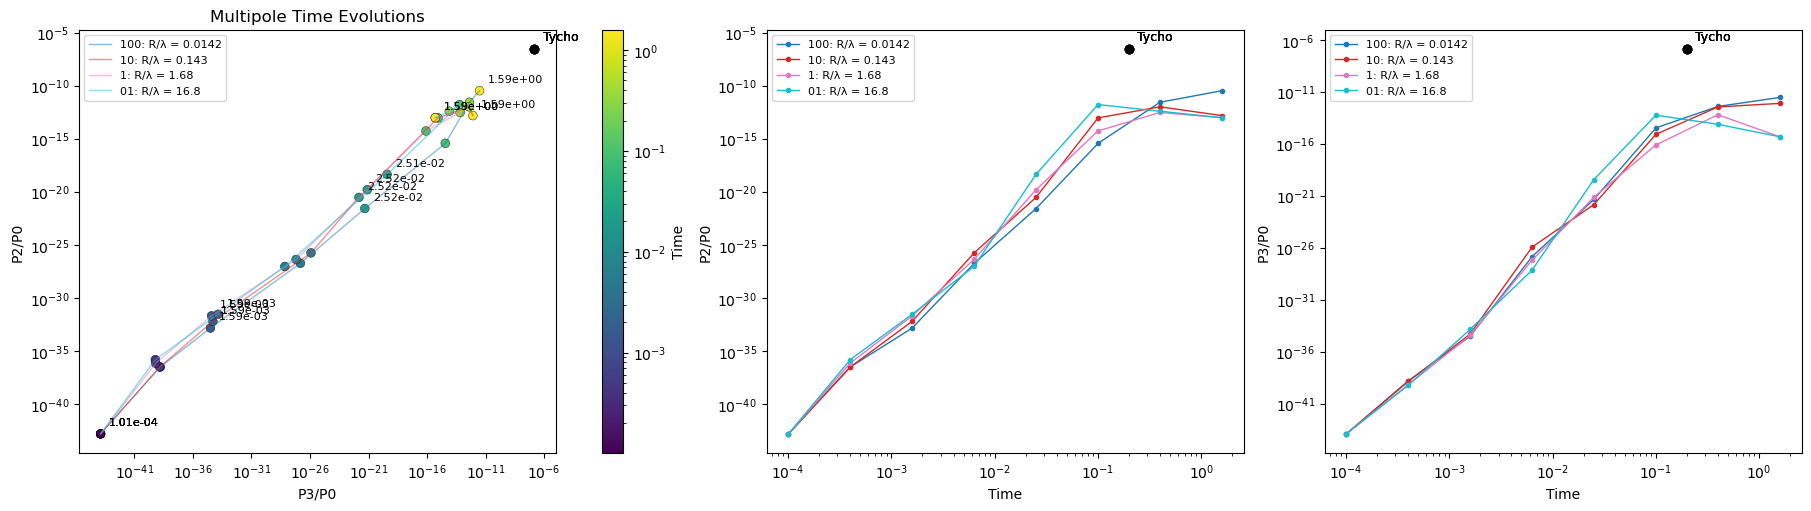

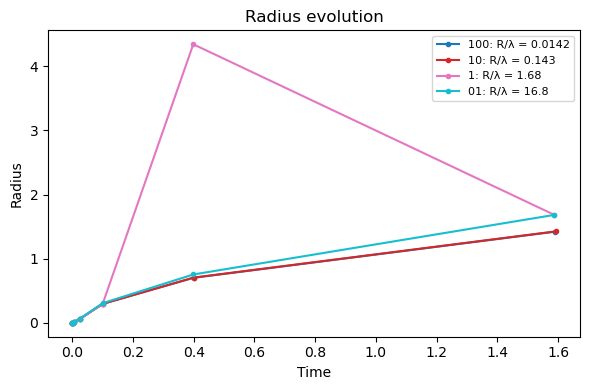

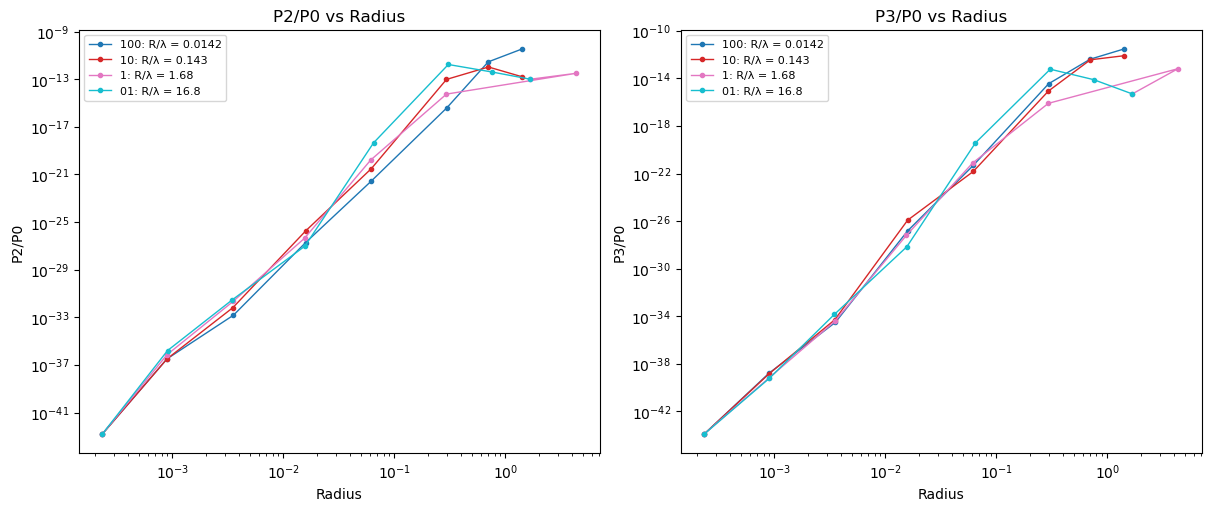

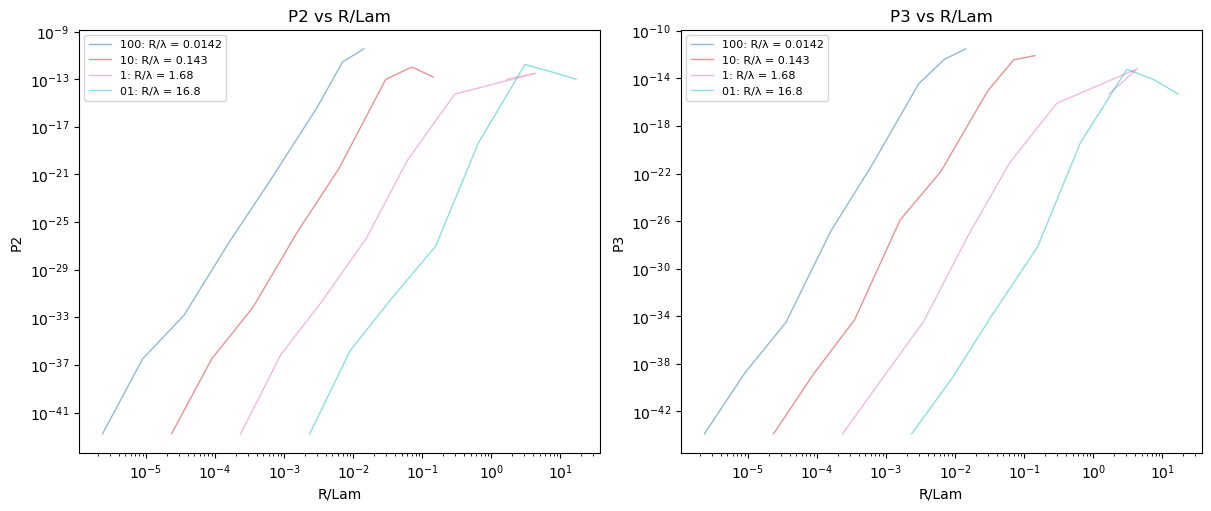

In [ ]:

'''
This script is designed to process simulation data from multiple folders, each representing different simulation conditions. 
It retrieves data files, applies transformations, calculates multipole moments, and generates plots for analysis. 
The main function iterates through specified folders and file numbers, processes the data, and stores the results for later visualization.
This script was recently split into multiple files for better organization, with each file handling specific tasks such as data retrieval, processing, and plotting.
'''

import numpy as np
from config import PRESSURECUTOFF, PARAMETERS, INCREMENT
from data_io import dataRetriever, pressureParser, dataMirrorer, lambdaFromFolder
from processing import magneticField, getRadius, dataRotator, CenterOfMass
from multipoles import multipoleCalculator
from plotting import finalPlots, plotFiles

#MAIN FUNCTION#------------------------------------------------------------------------------
baseDirectory = "/Users/camoc/OneDrive/Desktop/Research/ExpGradCollection/"
folderList = ["100", "10", "1", "01"]   # simulations to compare
fileNumberList = list(range(0, 40, 5))          # List of file numbers to process
theta = 90  # Rotation angle in degrees for theta
phi = 0    # Rotation angle in degrees for phi

# Results stored per-folder so each simulation becomes its own line later
allMultipoleData = {}   
allTimeSteps = {}       
allRadii = {}           

for folder in folderList:
    fileExtension = baseDirectory + folder + "/checkpoint_"

    processedData = []
    multipoleData = []
    timeSteps = []
    radii = []

    # File retrieving and modifying
    for fileNumber in fileNumberList:
        mirroredData, size, time, dx = dataRetriever(fileExtension, fileNumber)
        mirroredData[0] = magneticField(mirroredData, size)
        timeSteps.append(time)
        radius = getRadius(mirroredData, size, dx)
        radii.append(radius)

        if [theta, phi] != [0, 0]:
            rotatedData = dataRotator(mirroredData, theta, phi, size, fileNumber) # Rotate Data
        else:
            rotatedData = mirroredData

        processedData.append(rotatedData)

        plotData = np.sum(rotatedData[0], axis=1)  # Collapse density to 2d image
        [CenterX, CenterY] = CenterOfMass(plotData, size)
        moments = []
        for m in range(0, 4):
            moments.append(multipoleCalculator(plotData, size, CenterX, CenterY, INCREMENT, m, size))

        print(f'[{folder}] P2/P0 = {moments[2] / moments[0]}\nP3/P0 = {moments[3] / moments[0]}\n')
        multipoleData.append([moments[2] / moments[0], moments[3] / moments[0]])

    print(f'{folder} timeSteps: {timeSteps}')

    # Optional: only plot checkpoint images for one folder to avoid a flood of figures
    # plotFiles(processedData, fileNumberList, max_cols=3)

    allMultipoleData[folder] = multipoleData
    allTimeSteps[folder] = timeSteps
    allRadii[folder] = radii

finalPlots(allMultipoleData, folderList, allTimeSteps, allRadii) # Plot results


